# Step 1: EDA & Understanding Class Imbalance

**Goal of this project:** detect fraudulent credit card transactions - a **binary classification** problem (fraud vs. not fraud) with a twist that makes it genuinely hard: fraud is *rare*. Real fraud detection systems face exactly this challenge, and the way you measure success matters as much as the model itself - a model that looks great on paper can be useless in practice if you're using the wrong yardstick. This step is about understanding that problem before touching any model.

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), collected by the Machine Learning Group at Université Libre de Bruxelles (ULB) in collaboration with Worldline. 284,807 real credit card transactions from European cardholders over two days in September 2013. Downloaded here from a [Zenodo mirror](https://zenodo.org/records/7395559) (CC-BY-4.0) of the same file, since Kaggle's own download requires a login.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/creditcard.csv")
df.shape

(284807, 31)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**What each column means:**

| Column | Meaning |
|---|---|
| `Time` | Seconds elapsed since the first transaction in the dataset |
| `V1`-`V28` | The original transaction details (merchant, location, card details, etc.), transformed via **PCA** for confidentiality - the bank couldn't publish raw customer data, so these 28 columns are anonymized numerical features that still capture the underlying patterns, just without revealing what they literally represent |
| `Amount` | Transaction amount, in euros |
| `Class` | **Target column**: 1 = fraud, 0 = legitimate |

**What is PCA, briefly?** Principal Component Analysis takes many correlated original features and compresses them into fewer new features that preserve most of the important patterns, without needing the original, sensitive columns. Useful here for exactly that reason: the bank can share this dataset publicly without exposing real cardholder data.

## Missing values and duplicates

In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0


Duplicate rows: 1081


No missing values. 1,081 exact duplicate rows - and this time, unlike the salary survey in Project 3, there's a strong reason to believe these **are** errors, not coincidences: each row has 30 continuous numerical columns (`Time`, 28 PCA features, `Amount`), most with many decimal places. The odds of two genuinely different transactions landing on bit-for-bit identical values across all 30 continuous columns by pure chance are astronomically small - this pattern only makes sense as duplicate log entries (e.g. a transaction recorded twice during data collection). We remove them.

In [4]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows -> {len(df)} rows remain")

Removed 1081 duplicate rows -> 283726 rows remain


## The class imbalance

This is the central challenge of the whole project.

In [5]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print()
print(f"Legitimate: {class_pct[0]:.3f}%")
print(f"Fraud:      {class_pct[1]:.3f}%")

Class
0    283253
1       473
Name: count, dtype: int64

Legitimate: 99.833%
Fraud:      0.167%


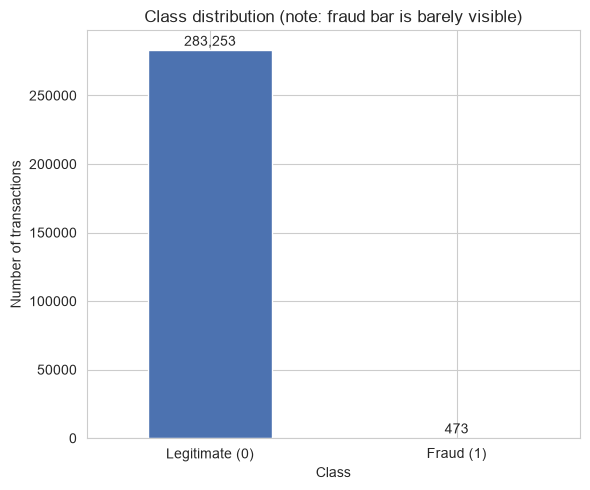

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
class_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Number of transactions")
ax.set_title("Class distribution (note: fraud bar is barely visible)")
for i, v in enumerate(class_counts):
    ax.text(i, v + 3000, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig("assets/class_distribution.png", dpi=120)
plt.show()

Only 473 fraud cases out of 283,726 transactions - **0.167%**. The fraud bar in the chart above is basically invisible next to the legitimate bar. That's not a data quality issue to fix; it's the actual, honest shape of the real-world problem - fraud is supposed to be rare.

## Why accuracy is the wrong metric here

**This is the single most important idea in this project.** Imagine the laziest possible "model": one that always predicts "legitimate", no matter what.

In [7]:
naive_accuracy = (df["Class"] == 0).mean()
print(f"Accuracy of a model that always predicts 'legitimate': {naive_accuracy*100:.3f}%")

Accuracy of a model that always predicts 'legitimate': 99.833%


**99.83% accuracy, while catching zero fraud cases, ever.** That number looks fantastic and is completely useless - it's a model that does the *opposite* of the one thing it's supposed to do. If Step 2 reports a model's "accuracy" without context, that number is nearly meaningless here: a model has to beat 99.83% by a wide margin while *also* actually catching fraud, or it hasn't proven anything. This is exactly why fraud detection (and other rare-event problems: disease screening, defect detection, spam filtering) uses different metrics - **precision** (of the transactions flagged as fraud, how many really were fraud?) and **recall** (of the real fraud cases, how many did the model actually catch?) - covered properly once a real model exists to evaluate, in Step 2.

## Does transaction amount differ between fraud and legitimate?

In [8]:
print(df.groupby("Class")["Amount"].describe().round(2))

          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


/var/folders/_3/4d6h0xnn2lz4st1sn4ltrtl40000gn/T/ipykernel_11369/4036338597.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legitimate", "Fraud"])


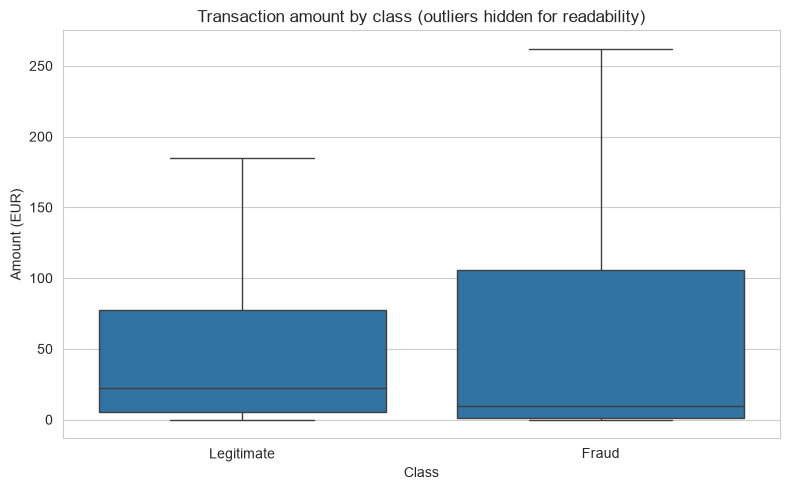

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Class", y="Amount", ax=ax, showfliers=False)
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_ylabel("Amount (EUR)")
ax.set_title("Transaction amount by class (outliers hidden for readability)")
plt.tight_layout()
plt.savefig("assets/amount_by_class.png", dpi=120)
plt.show()

Interesting: fraudulent transactions have a **lower median amount** (9.25 EUR) than legitimate ones (22.00 EUR), though a higher mean (122 vs. 88 EUR) - fraud amounts are more spread out, with both very small "test" charges and some large ones, while legitimate spending clusters more predictably. `Amount` alone won't cleanly separate the two classes, but it's a real, informative signal - not something fraud detection can ignore.

## Summary

- Removed 1,081 duplicate rows - justified this time by the near-impossibility of coincidental duplicates across 30 continuous columns (unlike Project 3's salary survey, where duplicates were expected and kept).
- **Severe class imbalance**: only 0.167% of transactions are fraud.
- **Accuracy is a trap here**: a model that never predicts fraud already scores 99.83% - Step 2 needs precision/recall, not accuracy, to mean anything.
- `Amount` differs somewhat between classes but isn't a clean separator on its own - real signal, not a silver bullet.

Next: Step 2 trains a first (baseline) model and evaluates it with metrics that actually make sense for this problem.